# Naive Bayes Tutorial with scikit-learn

**Goal:** Build intuition for Naive Bayes through tiny hand-calculation examples, then implement several Naive Bayes models with `scikit-learn`.

By the end, you should be able to:

1. Explain Bayes' theorem and the *naive conditional independence assumption*.
2. Calculate a tiny Naive Bayes prediction by hand.
3. Choose the right scikit-learn Naive Bayes variant:
   - `CategoricalNB` for categorical/discrete categories
   - `MultinomialNB` for count features, often word counts
   - `BernoulliNB` for binary features
   - `GaussianNB` for continuous numeric features
   - `ComplementNB` as a common alternative for imbalanced text classification
4. Interpret important hyperparameters such as `alpha`, `fit_prior`, `class_prior`, `binarize`, and `var_smoothing`.
5. Evaluate and compare models using accuracy, confusion matrix, and classification report.

Official references:
- scikit-learn User Guide: Naive Bayes — https://scikit-learn.org/stable/modules/naive_bayes.html
- `GaussianNB` — https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html
- `MultinomialNB` — https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html
- `BernoulliNB` — https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html
- `CategoricalNB` — https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.CategoricalNB.html

## 1. The basic idea

Naive Bayes is a probabilistic classifier based on Bayes' theorem.

For a class $y$ and feature vector $x = (x_1, x_2, \dots, x_n)$:

$$
P(y \mid x_1, \dots, x_n)
=
\frac{
P(y)P(x_1, \dots, x_n \mid y)
}{
P(x_1, \dots, x_n)
}
$$

For classification, the denominator is the same for all classes, so we compare:

$$
\hat{y}
=
\arg\max_y P(y)P(x_1, \dots, x_n \mid y)
$$

The **naive assumption** says that features are conditionally independent given the class:

$$
P(x_1, \dots, x_n \mid y)
=
\prod_{i=1}^{n} P(x_i \mid y)
$$

So the classifier becomes:

$$
\hat{y}
=
\arg\max_y P(y)\prod_{i=1}^{n}P(x_i \mid y)
$$

In practice, implementations often use **log probabilities** to avoid numerical underflow:

$$
\hat{y}
=
\arg\max_y \left[
\log P(y) + \sum_{i=1}^{n}\log P(x_i \mid y)
\right]
$$

## 2. Tiny hand-calculation example: Categorical Naive Bayes

Suppose we want to predict whether a student will **Pass** or **Fail** based on:

- `Study`: high or low
- `Sleep`: enough or little

Training data:

| Student | Study | Sleep | Result |
|---|---|---|---|
| 1 | high | enough | Pass |
| 2 | high | little | Pass |
| 3 | low | enough | Pass |
| 4 | low | little | Fail |
| 5 | low | little | Fail |
| 6 | high | little | Fail |

We want to classify a new student:

$$
x = (\text{Study=high}, \text{Sleep=little})
$$

### Step 1: Class priors

There are 3 Pass and 3 Fail examples.

$$
P(\text{Pass}) = \frac{3}{6} = 0.5
$$

$$
P(\text{Fail}) = \frac{3}{6} = 0.5
$$

### Step 2: Conditional probabilities

For class **Pass**:

- Pass rows:  
  `(high, enough)`, `(high, little)`, `(low, enough)`

$$
P(\text{Study=high} \mid \text{Pass}) = \frac{2}{3}
$$

$$
P(\text{Sleep=little} \mid \text{Pass}) = \frac{1}{3}
$$

For class **Fail**:

- Fail rows:  
  `(low, little)`, `(low, little)`, `(high, little)`

$$
P(\text{Study=high} \mid \text{Fail}) = \frac{1}{3}
$$

$$
P(\text{Sleep=little} \mid \text{Fail}) = \frac{3}{3}=1
$$

### Step 3: Compare posterior scores

$$
\text{Score(Pass)}
=
P(\text{Pass})
P(\text{Study=high} \mid \text{Pass})
P(\text{Sleep=little} \mid \text{Pass})
$$

$$
= 0.5 \times \frac{2}{3}\times \frac{1}{3}
= \frac{1}{9}
\approx 0.111
$$

$$
\text{Score(Fail)}
=
P(\text{Fail})
P(\text{Study=high} \mid \text{Fail})
P(\text{Sleep=little} \mid \text{Fail})
$$

$$
= 0.5 \times \frac{1}{3}\times 1
= \frac{1}{6}
\approx 0.167
$$

Since $0.167 > 0.111$, the prediction is:

$$
\hat{y} = \text{Fail}
$$

Notice that Naive Bayes does not claim this is certainly Fail. It only says that **Fail has the larger probability score under this simple model**.

In [1]:
# Tiny hand calculation in Python

p_pass = 3 / 6
p_fail = 3 / 6

p_study_high_given_pass = 2 / 3
p_sleep_little_given_pass = 1 / 3

p_study_high_given_fail = 1 / 3
p_sleep_little_given_fail = 3 / 3

score_pass = p_pass * p_study_high_given_pass * p_sleep_little_given_pass
score_fail = p_fail * p_study_high_given_fail * p_sleep_little_given_fail

print("Score(Pass):", score_pass)
print("Score(Fail):", score_fail)
print("Prediction:", "Pass" if score_pass > score_fail else "Fail")

Score(Pass): 0.1111111111111111
Score(Fail): 0.16666666666666666
Prediction: Fail


## 3. The zero-probability problem and Laplace smoothing

Naive Bayes multiplies conditional probabilities. If one probability is zero, the whole class score becomes zero.

Example:

Assume in the training data no **Pass** student has `Sleep=very_little`.

Then:

$$
P(\text{Sleep=very\_little} \mid \text{Pass}) = 0
$$

This makes:

$$
P(\text{Pass})P(\text{Study=high}\mid\text{Pass})P(\text{Sleep=very\_little}\mid\text{Pass}) = 0
$$

Even if other features strongly support Pass, the score becomes zero.

### Additive smoothing

For categorical features, scikit-learn uses additive smoothing controlled by `alpha`.

$$
P(x_i=t \mid y=c)
=
\frac{N_{tic} + \alpha}{N_c + \alpha n_i}
$$

where:

- $N_{tic}$: count of category \(t\) for feature \(i\) in class \(c\)
- $N_c$: number of samples in class \(c\)
- $n_i$: number of possible categories for feature \(i\)
- $\alpha$: smoothing strength

Common settings:

- `alpha=1.0`: Laplace smoothing
- `alpha<1.0`: weaker smoothing
- `alpha=0.0`: no smoothing; can create zero probabilities

In [2]:
# Laplace smoothing example

# Suppose Sleep has 3 possible categories: enough, little, very_little
# In Pass class, there are 3 samples.
# Count(Sleep=very_little, Pass) = 0

N_tic = 0
N_c = 3
n_i = 3

for alpha in [0.0, 0.1, 1.0, 10.0]:
    probability = (N_tic + alpha) / (N_c + alpha * n_i)
    print(f"alpha={alpha:>4}: P(Sleep=very_little | Pass) = {probability:.4f}")

alpha= 0.0: P(Sleep=very_little | Pass) = 0.0000
alpha= 0.1: P(Sleep=very_little | Pass) = 0.0303
alpha= 1.0: P(Sleep=very_little | Pass) = 0.1667
alpha=10.0: P(Sleep=very_little | Pass) = 0.3030


## 4. Implement Categorical Naive Bayes in scikit-learn

`CategoricalNB` is suitable when features are discrete categories, for example:

- color: red/green/blue
- device type: mobile/tablet/desktop
- study level: low/medium/high

scikit-learn expects categorical features to be encoded as non-negative integers.

In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB

data = pd.DataFrame({
    "Study": ["high", "high", "low", "low", "low", "high"],
    "Sleep": ["enough", "little", "enough", "little", "little", "little"],
    "Result": ["Pass", "Pass", "Pass", "Fail", "Fail", "Fail"]
})

data

,Study,Sleep,Result
0,high,enough,Pass
1,high,little,Pass
2,low,enough,Pass
3,low,little,Fail
4,low,little,Fail
5,high,little,Fail


In [4]:
X = data[["Study", "Sleep"]]
y = data["Result"]

feature_encoder = OrdinalEncoder()
target_encoder = LabelEncoder()

X_encoded = feature_encoder.fit_transform(X)
y_encoded = target_encoder.fit_transform(y)

print("Feature categories:", feature_encoder.categories_)
print("Target classes:", target_encoder.classes_)
print("\nEncoded X:")
print(X_encoded)
print("\nEncoded y:")
print(y_encoded)

Feature categories: [array(['high', 'low'], dtype=object), array(['enough', 'little'], dtype=object)]
Target classes: ['Fail' 'Pass']

Encoded X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]
 [1. 1.]
 [0. 1.]]

Encoded y:
[1 1 1 0 0 0]


In [5]:
cat_nb = CategoricalNB(alpha=1.0)
cat_nb.fit(X_encoded, y_encoded)

new_student = pd.DataFrame({
    "Study": ["high"],
    "Sleep": ["little"]
})

new_student_encoded = feature_encoder.transform(new_student)

pred_encoded = cat_nb.predict(new_student_encoded)
pred_label = target_encoder.inverse_transform(pred_encoded)

pred_proba = cat_nb.predict_proba(new_student_encoded)

print("New student:")
display(new_student)

print("Predicted class:", pred_label[0])
print("Class probabilities:")
for cls, prob in zip(target_encoder.classes_, pred_proba[0]):
    print(f"{cls}: {prob:.3f}")

New student:


,Study,Sleep
0,high,little


Predicted class: Fail
Class probabilities:
Fail: 0.571
Pass: 0.429


### Exercise 1

Change `alpha` in `CategoricalNB(alpha=...)`.

Try:

```python
alpha=0.0
alpha=0.1
alpha=1.0
alpha=10.0
```

Questions:

1. Does the prediction change?
2. Do the predicted probabilities change?
3. Why does large `alpha` make probabilities more similar?

## 5. Multinomial Naive Bayes for text classification

`MultinomialNB` is commonly used for text classification with word-count features.

Example task:

Classify short messages as:

- `sports`
- `tech`

The model does not understand meaning like a human. It learns word frequencies per class.

### Tiny text example by hand

Training data:

| Text | Class |
|---|---|
| team win game | sports |
| team score win | sports |
| computer code bug | tech |
| code software computer | tech |

Vocabulary:

$$
[\text{team}, \text{win}, \text{game}, \text{score}, \text{computer}, \text{code}, \text{bug}, \text{software}]
$$

Class priors:

$$
P(\text{sports}) = \frac{2}{4}=0.5
$$

$$
P(\text{tech}) = \frac{2}{4}=0.5
$$

Word counts in `sports`:

- team: 2
- win: 2
- game: 1
- score: 1
- total words: 6

Word counts in `tech`:

- computer: 2
- code: 2
- bug: 1
- software: 1
- total words: 6

Without smoothing:

$$
P(\text{code}\mid\text{sports}) = 0
$$

That is dangerous because a single unseen word can make a class score zero.

With Laplace smoothing $\alpha=1$ and vocabulary size \(V=8\):

$$
P(w\mid c) = \frac{\text{count}(w,c)+1}{\text{total words in class }c + V}
$$

For a new text:

```text
team code
```

For sports:

$$
P(\text{team}\mid\text{sports}) = \frac{2+1}{6+8} = \frac{3}{14}
$$

$$
P(\text{code}\mid\text{sports}) = \frac{0+1}{6+8} = \frac{1}{14}
$$

$$
\text{Score(sports)}
= 0.5 \times \frac{3}{14} \times \frac{1}{14}
\approx 0.00765
$$

For tech:

$$
P(\text{team}\mid\text{tech}) = \frac{0+1}{6+8} = \frac{1}{14}
$$

$$
P(\text{code}\mid\text{tech}) = \frac{2+1}{6+8} = \frac{3}{14}
$$

$$
\text{Score(tech)}
= 0.5 \times \frac{1}{14} \times \frac{3}{14}
\approx 0.00765
$$

The scores are equal because the message contains one word strongly associated with each class.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

texts = [
    "team win game",
    "team score win",
    "computer code bug",
    "code software computer"
]

labels = ["sports", "sports", "tech", "tech"]

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(texts)

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nDocument-term matrix:")
pd.DataFrame(X_counts.toarray(), columns=vectorizer.get_feature_names_out())

Vocabulary:
['bug' 'code' 'computer' 'game' 'score' 'software' 'team' 'win']

Document-term matrix:


,bug,code,computer,game,score,software,team,win
0,0,0,0,1,0,0,1,1
1,0,0,0,0,1,0,1,1
2,1,1,1,0,0,0,0,0
3,0,1,1,0,0,1,0,0


In [8]:
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_counts, labels)

test_texts = ["team code", "team win", "software bug", "team score game"]
X_test_counts = vectorizer.transform(test_texts)

predictions = mnb.predict(X_test_counts)
probabilities = mnb.predict_proba(X_test_counts)

results = pd.DataFrame(probabilities, columns=mnb.classes_)
results.insert(0, "text", test_texts)
results["prediction"] = predictions
results

,text,sports,tech,prediction
0,team code,0.500000,0.500000,sports
1,team win,0.900000,0.100000,sports
2,software bug,0.200000,0.800000,tech
3,team score game,0.923077,0.076923,sports


### Exercise 2

Try these new messages:

```python
"team team win"
"code code software"
"game bug"
"unknownword"
```

Questions:

1. What happens when a word is not in the vocabulary?
2. Why does repeating a word affect `MultinomialNB`?
3. Why is `MultinomialNB` often a strong baseline for text classification?

## 6. Bernoulli Naive Bayes for binary features

`BernoulliNB` is different from `MultinomialNB`.

- `MultinomialNB`: uses counts  
  Example: the word `"win"` appears 3 times.
- `BernoulliNB`: uses binary presence/absence  
  Example: the word `"win"` appears or does not appear.

This can be useful when presence is more important than frequency.

In [9]:
from sklearn.naive_bayes import BernoulliNB

# Binary document-term features: CountVectorizer(binary=True)
binary_vectorizer = CountVectorizer(binary=True)
X_binary = binary_vectorizer.fit_transform(texts)

print("Binary document-term matrix:")
display(pd.DataFrame(X_binary.toarray(), columns=binary_vectorizer.get_feature_names_out()))

bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_binary, labels)

test_texts = ["team team team code", "team code", "software bug", "team score game"]
X_test_binary = binary_vectorizer.transform(test_texts)

predictions = bnb.predict(X_test_binary)
probabilities = bnb.predict_proba(X_test_binary)

results = pd.DataFrame(probabilities, columns=bnb.classes_)
results.insert(0, "text", test_texts)
results["prediction"] = predictions
results

Binary document-term matrix:


,bug,code,computer,game,score,software,team,win
0,0,0,0,1,0,0,1,1
1,0,0,0,0,1,0,1,1
2,1,1,1,0,0,0,0,0
3,0,1,1,0,0,1,0,0


,text,sports,tech,prediction
0,team team team code,0.500000,0.500000,sports
1,team code,0.500000,0.500000,sports
2,software bug,0.100000,0.900000,tech
3,team score game,0.987805,0.012195,sports


### Important hyperparameter: `binarize`

`BernoulliNB` has a `binarize` parameter.

If `binarize=0.0`, values greater than 0 become 1 and values less than or equal to 0 become 0.

If `binarize=None`, the input is assumed to already be binary.

In text classification, a common strategy is:

```python
CountVectorizer(binary=True)
BernoulliNB(binarize=None)
```

## 7. Gaussian Naive Bayes for continuous numeric features

`GaussianNB` assumes that continuous features follow a normal distribution within each class.

For each feature and each class, it estimates:

- mean $\mu$
- variance $\sigma^2$

The likelihood is:

$$
P(x_i \mid y=c)
=
\frac{1}{\sqrt{2\pi\sigma_c^2}}
\exp\left(
-\frac{(x_i-\mu_c)^2}{2\sigma_c^2}
\right)
$$

Then it multiplies the feature likelihoods under the naive independence assumption.

We will use the Iris dataset and classify flowers using two continuous features:

- petal length
- petal width

In [10]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.naive_bayes import GaussianNB

iris = load_iris(as_frame=True)
df = iris.frame.copy()

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
# Use only two features to make visualization easier
feature_names = ["petal length (cm)", "petal width (cm)"]
X = df[feature_names]
y = df["target"]

target_names = iris.target_names
print("Target names:", target_names)

Target names: ['setosa' 'versicolor' 'virginica']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9333333333333333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



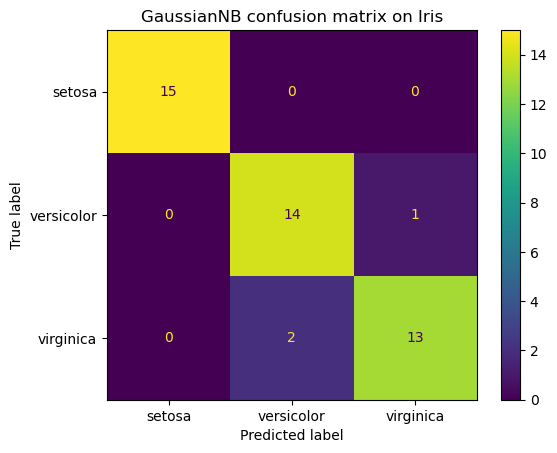

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot()
plt.title("GaussianNB confusion matrix on Iris")
plt.show()

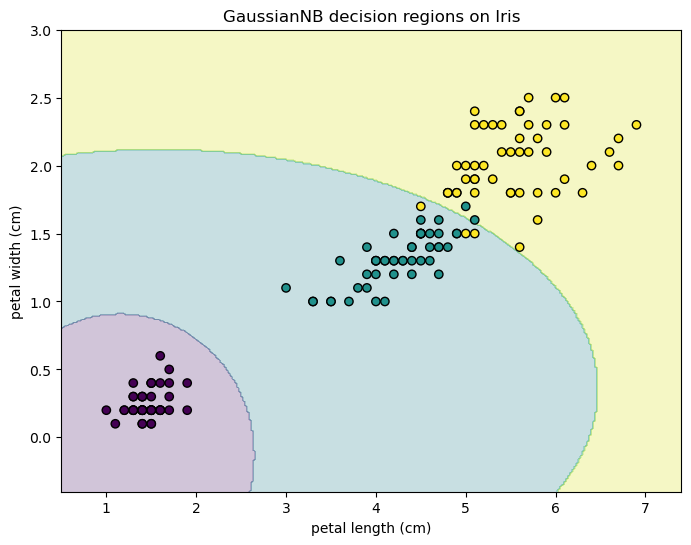

In [14]:
# Visualize the decision regions for the two selected features

import numpy as np

x_min, x_max = X[feature_names[0]].min() - 0.5, X[feature_names[0]].max() + 0.5
y_min, y_max = X[feature_names[1]].min() - 0.5, X[feature_names[1]].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=feature_names
)

Z = gnb.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)
scatter = plt.scatter(
    X[feature_names[0]],
    X[feature_names[1]],
    c=y,
    edgecolor="k"
)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("GaussianNB decision regions on Iris")
plt.show()

### Inspect what GaussianNB learned

`GaussianNB` estimates a mean and variance for each feature in each class.

In [15]:
means = pd.DataFrame(
    gnb.theta_,
    columns=feature_names,
    index=target_names
)

variances = pd.DataFrame(
    gnb.var_,
    columns=feature_names,
    index=target_names
)

print("Class priors learned by the model:")
display(pd.Series(gnb.class_prior_, index=target_names, name="class_prior"))

print("Feature means per class:")
display(means)

print("Feature variances per class:")
display(variances)

Class priors learned by the model:


setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: class_prior, dtype: float64

Feature means per class:


,petal length (cm),petal width (cm)
setosa,1.485714,0.240000
versicolor,4.237143,1.308571
virginica,5.631429,2.068571


Feature variances per class:


,petal length (cm),petal width (cm)
setosa,0.022939,0.009257
versicolor,0.211478,0.035641
virginica,0.322727,0.063869


### Tiny Gaussian calculation by hand

Suppose one feature is `exam_score`.

For class **Pass**, assume:

$$
\mu_{\text{Pass}} = 80,\quad \sigma^2_{\text{Pass}} = 25
$$

For class **Fail**, assume:

$$
\mu_{\text{Fail}} = 50,\quad \sigma^2_{\text{Fail}} = 100
$$

A new student has:

$$
x = 70
$$

The Gaussian likelihood is:

$$
P(x \mid y=c)
=
\frac{1}{\sqrt{2\pi\sigma_c^2}}
\exp\left(
-\frac{(x-\mu_c)^2}{2\sigma_c^2}
\right)
$$

We calculate both likelihoods and multiply by class priors.

In [16]:
import math

def gaussian_pdf(x, mean, variance):
    return (1 / math.sqrt(2 * math.pi * variance)) * math.exp(-((x - mean) ** 2) / (2 * variance))

x = 70

p_pass_prior = 0.5
p_fail_prior = 0.5

likelihood_pass = gaussian_pdf(x, mean=80, variance=25)
likelihood_fail = gaussian_pdf(x, mean=50, variance=100)

score_pass = p_pass_prior * likelihood_pass
score_fail = p_fail_prior * likelihood_fail

print("Likelihood Pass:", likelihood_pass)
print("Likelihood Fail:", likelihood_fail)
print("Score Pass:", score_pass)
print("Score Fail:", score_fail)
print("Prediction:", "Pass" if score_pass > score_fail else "Fail")

Likelihood Pass: 0.01079819330263761
Likelihood Fail: 0.005399096651318805
Score Pass: 0.005399096651318805
Score Fail: 0.0026995483256594026
Prediction: Pass


## 8. Important hyperparameters in scikit-learn

### Common parameters

#### `fit_prior`

If `fit_prior=True`, the model learns class priors from the training data.

If `fit_prior=False`, it uses uniform class priors.

This can affect imbalanced datasets.

#### `class_prior`

You can manually specify class priors.

Example:

```python
GaussianNB(class_prior=[0.7, 0.3])
```

This means the model assumes class 0 is more common before seeing the features.

### Smoothing parameters

#### `alpha`

Used in:

- `MultinomialNB`
- `BernoulliNB`
- `CategoricalNB`
- `ComplementNB`

It controls additive smoothing.

Large `alpha` makes conditional probabilities less extreme.

#### `var_smoothing`

Used in:

- `GaussianNB`

It adds a small value to variances for numerical stability.

A larger value can make the model less sensitive to very small estimated variances.

In [17]:
# Effect of alpha on MultinomialNB probabilities

alphas = [0.0, 0.1, 1.0, 10.0]
test_text = ["team code"]
X_test = vectorizer.transform(test_text)

for alpha in alphas:
    model = MultinomialNB(alpha=alpha, force_alpha=True)
    model.fit(X_counts, labels)
    proba = model.predict_proba(X_test)[0]
    print(f"alpha={alpha}")
    for cls, p in zip(model.classes_, proba):
        print(f"  {cls}: {p:.4f}")
    print()

alpha=0.0
  sports: nan
  tech: nan

alpha=0.1
  sports: 0.5000
  tech: 0.5000

alpha=1.0
  sports: 0.5000
  tech: 0.5000

alpha=10.0
  sports: 0.5000
  tech: 0.5000



c:\Users\Lena\anaconda3\envs\p3.12\Lib\site-packages\sklearn\naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\Lena\anaconda3\envs\p3.12\Lib\site-packages\sklearn\naive_bayes.py:130: RuntimeWarning: invalid value encountered in subtract
  return jll - np.atleast_2d(log_prob_x).T


In [18]:
# Effect of fit_prior on an imbalanced toy dataset

imbalanced_texts = [
    "win team game",
    "score team win",
    "team game score",
    "team win match",
    "game score team",
    "software code bug"
]
imbalanced_labels = ["sports", "sports", "sports", "sports", "sports", "tech"]

vec = CountVectorizer()
X_imb = vec.fit_transform(imbalanced_texts)

test_texts = ["code bug", "team win", "code team"]
X_new = vec.transform(test_texts)

for fit_prior in [True, False]:
    model = MultinomialNB(alpha=1.0, fit_prior=fit_prior)
    model.fit(X_imb, imbalanced_labels)
    print("fit_prior =", fit_prior)
    print("learned class log prior:", dict(zip(model.classes_, model.class_log_prior_)))
    probs = model.predict_proba(X_new)
    display(pd.DataFrame(probs, columns=model.classes_).assign(text=test_texts, prediction=model.predict(X_new)))
    print()

fit_prior = True
learned class log prior: {np.str_('sports'): np.float64(-0.18232155679395468), np.str_('tech'): np.float64(-1.791759469228055)}


,sports,tech,text,prediction
0,0.222345,0.777655,code bug,tech
1,0.964848,0.035152,team win,sports
2,0.774317,0.225683,code team,sports



fit_prior = False
learned class log prior: {np.str_('sports'): np.float64(-0.6931471805599453), np.str_('tech'): np.float64(-0.6931471805599453)}


,sports,tech,text,prediction
0,0.054090,0.945910,code bug,tech
1,0.845907,0.154093,team win,sports
2,0.406951,0.593049,code team,tech


## 9. A more realistic text classification pipeline

In a real text problem, we should combine preprocessing and classification into a `Pipeline`.

Here we use a small built-in example dataset created manually to avoid external downloads. For a larger real dataset, scikit-learn provides `fetch_20newsgroups`, but it may require internet access on first run.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

texts = [
    "the team won the football match",
    "the coach discussed the game strategy",
    "the player scored a goal",
    "the tournament final was exciting",
    "the software update fixed the bug",
    "the code compiled successfully",
    "the developer wrote a new function",
    "the computer crashed after the update",
    "the match ended with a late goal",
    "the team trained for the tournament",
    "the bug appeared in the software",
    "the function improved the code performance",
]

labels = [
    "sports", "sports", "sports", "sports",
    "tech", "tech", "tech", "tech",
    "sports", "sports",
    "tech", "tech",
]

pipeline_mnb = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB(alpha=1.0))
])

scores = cross_val_score(pipeline_mnb, texts, labels, cv=3)

print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())

Cross-validation scores: [0.75 1.   1.  ]
Mean CV accuracy: 0.9166666666666666


In [20]:
pipeline_mnb.fit(texts, labels)

new_messages = [
    "the team scored a goal",
    "the software developer fixed the bug",
    "the coach wrote code",
    "the computer game was exciting"
]

pred = pipeline_mnb.predict(new_messages)
proba = pipeline_mnb.predict_proba(new_messages)

pd.DataFrame(proba, columns=pipeline_mnb.classes_).assign(
    text=new_messages,
    prediction=pred
)

,sports,tech,text,prediction
0,0.942408,0.057592,the team scored a goal,sports
1,0.022442,0.977558,the software developer fixed the bug,tech
2,0.232558,0.767442,the coach wrote code,tech
3,0.784314,0.215686,the computer game was exciting,sports


## 10. Complement Naive Bayes

`ComplementNB` is often useful for imbalanced text classification.

Instead of estimating each class directly in the standard multinomial way, it uses statistics from the complement of each class. This can improve performance when some classes dominate the dataset.

Use it mainly with count-like text features.

In [21]:
from sklearn.naive_bayes import ComplementNB

pipeline_cnb = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", ComplementNB(alpha=1.0))
])

scores = cross_val_score(pipeline_cnb, texts, labels, cv=3)

print("ComplementNB cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())

ComplementNB cross-validation scores: [0.75 1.   1.  ]
Mean CV accuracy: 0.9166666666666666


## 11. Choosing the right Naive Bayes variant

| Variant | Feature type | Common use case | Key hyperparameters |
|---|---|---|---|
| `GaussianNB` | Continuous numeric features | Iris/wine/medical numeric data | `priors`, `var_smoothing` |
| `MultinomialNB` | Counts or non-negative frequencies | Text classification with word counts or TF-IDF | `alpha`, `fit_prior`, `class_prior` |
| `BernoulliNB` | Binary/boolean features | Word presence/absence, yes/no indicators | `alpha`, `binarize`, `fit_prior` |
| `CategoricalNB` | Encoded categorical features | survey/category data | `alpha`, `fit_prior`, `min_categories` |
| `ComplementNB` | Count-like features | imbalanced text classification | `alpha`, `norm`, `fit_prior` |

### Practical rules

1. If your features are continuous: start with `GaussianNB`.
2. If your features are word counts: start with `MultinomialNB`.
3. If your text features are binary word presence: try `BernoulliNB`.
4. If your classes are imbalanced in text classification: try `ComplementNB`.
5. If your features are categories: use `CategoricalNB` with proper encoding.
6. Always compare with baselines such as logistic regression, linear SVM, or decision trees.

## 12. Mini project exercise

Use one of the following datasets:

1. `load_iris`
2. `load_wine`
3. `load_breast_cancer`
4. Your own short text dataset

Tasks:

1. Choose a Naive Bayes variant.
2. Explain why this variant matches the feature type.
3. Split the data into train/test.
4. Train the model.
5. Report:
   - accuracy
   - confusion matrix
   - classification report
6. Tune one relevant hyperparameter:
   - `alpha` for `MultinomialNB`, `BernoulliNB`, `CategoricalNB`, or `ComplementNB`
   - `var_smoothing` for `GaussianNB`
7. Explain how the hyperparameter changes the result.

In [22]:
# Template for the mini project: GaussianNB on wine dataset

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

for var_smoothing in [1e-12, 1e-9, 1e-6, 1e-3]:
    model = GaussianNB(var_smoothing=var_smoothing)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"var_smoothing={var_smoothing}: accuracy={acc:.3f}")

var_smoothing=1e-12: accuracy=1.000
var_smoothing=1e-09: accuracy=1.000
var_smoothing=1e-06: accuracy=1.000
var_smoothing=0.001: accuracy=0.759


In [23]:
# Final detailed evaluation with one selected setting

best_model = GaussianNB(var_smoothing=1e-9)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Accuracy: 1.0

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

